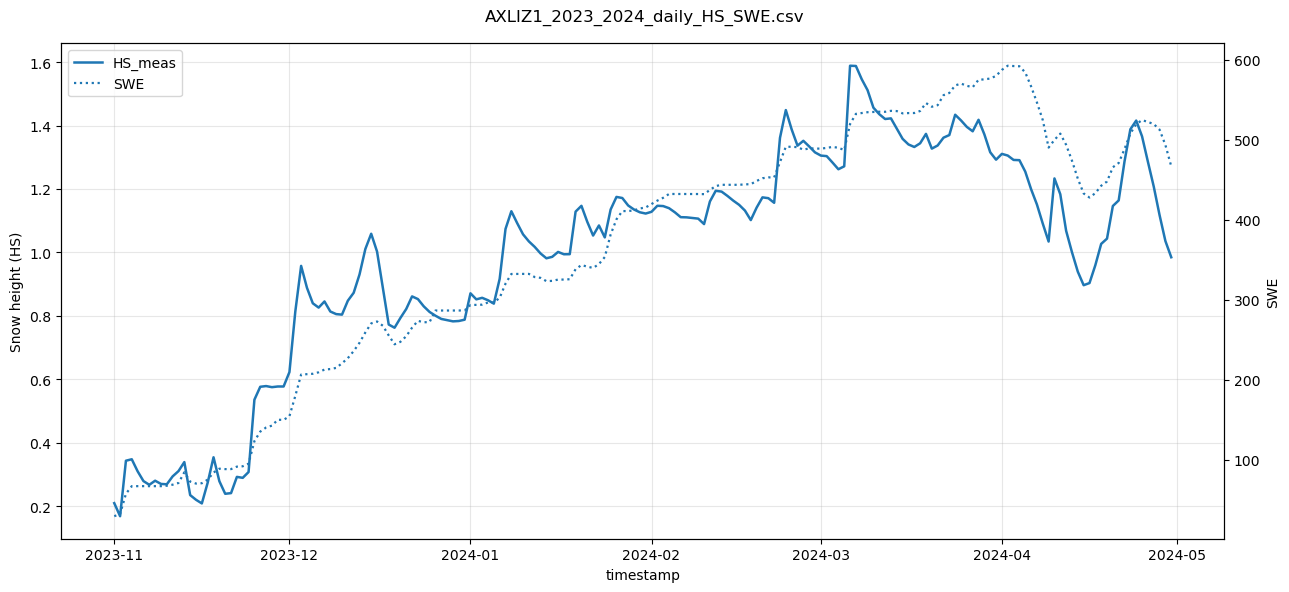

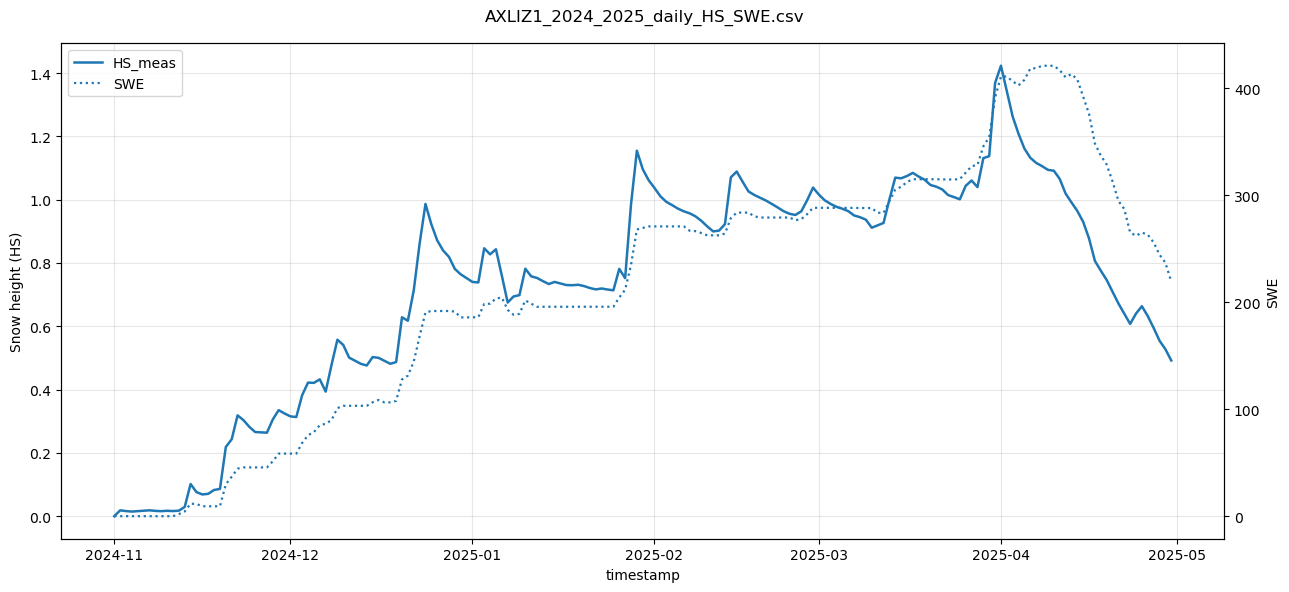

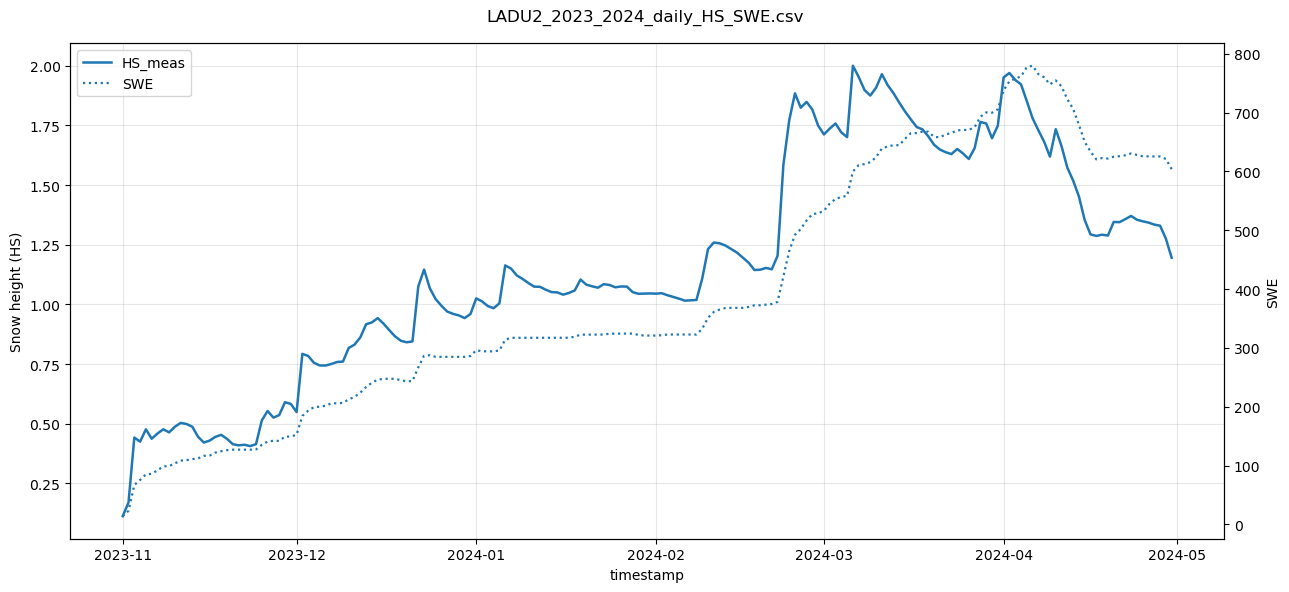

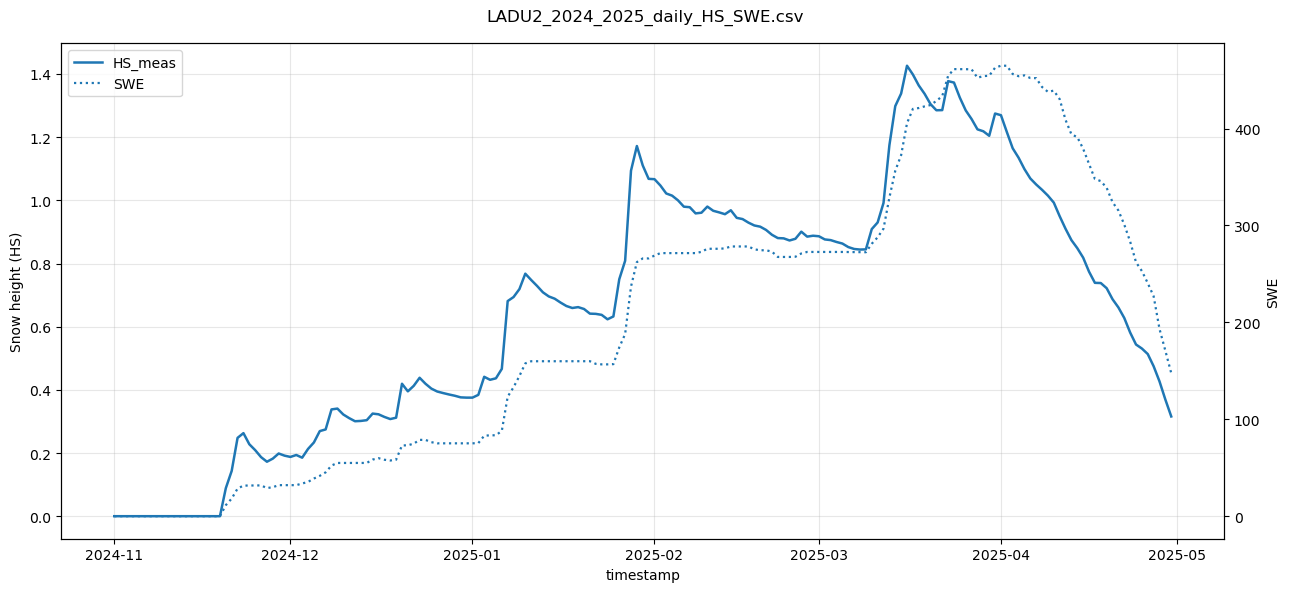

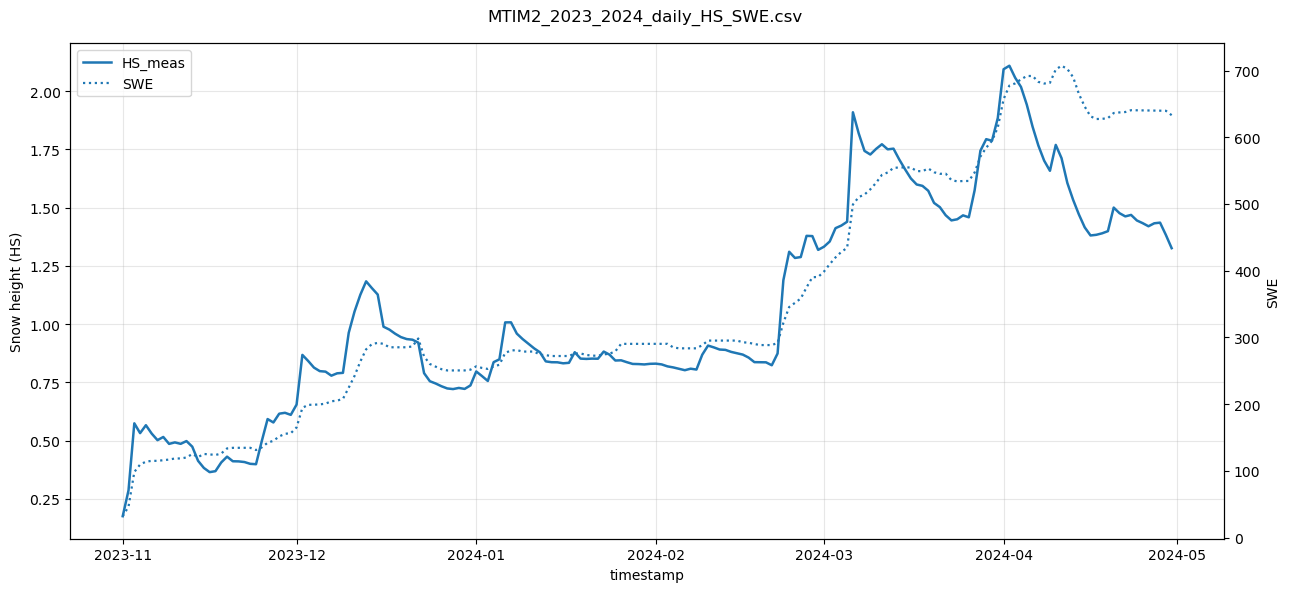

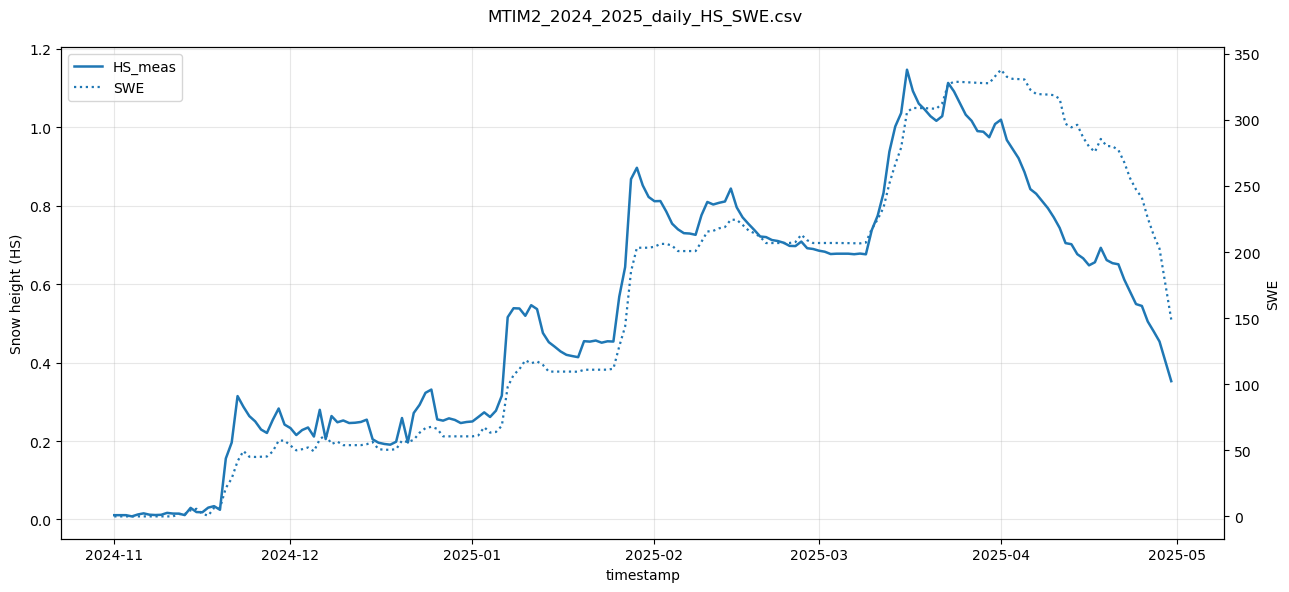

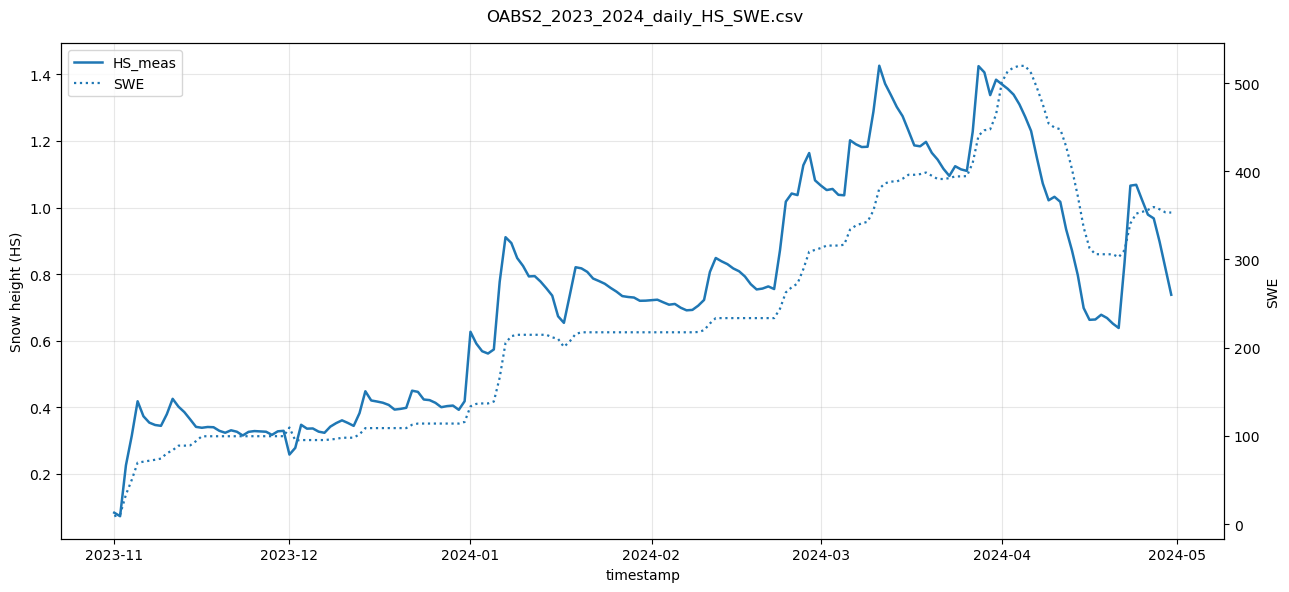

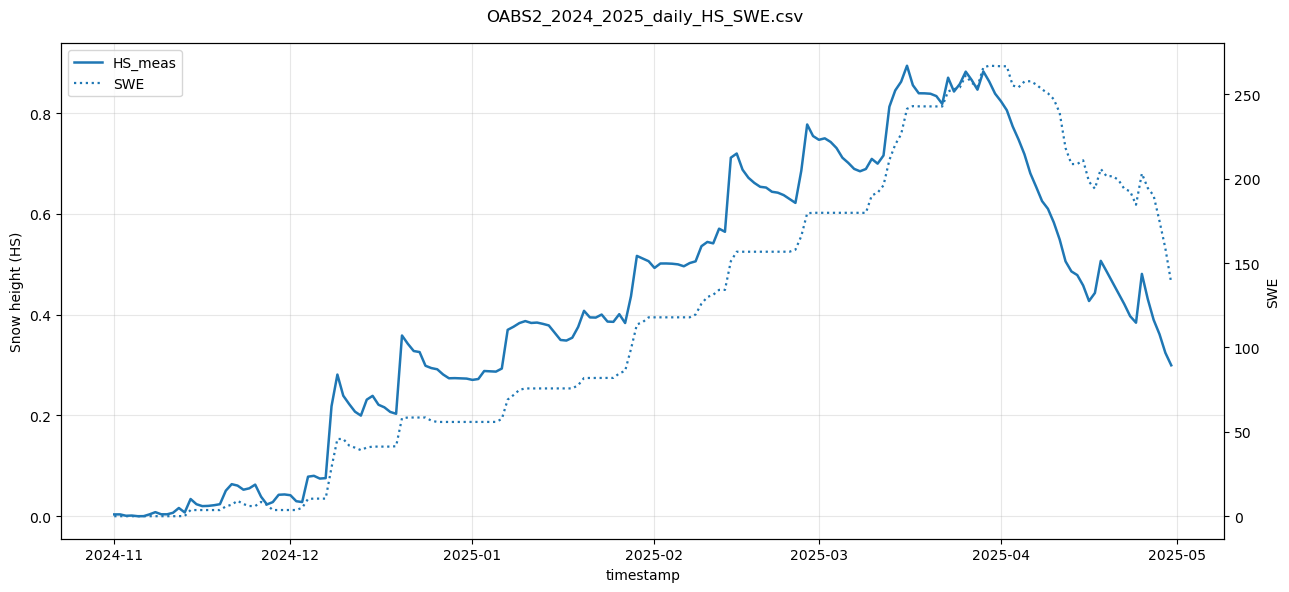

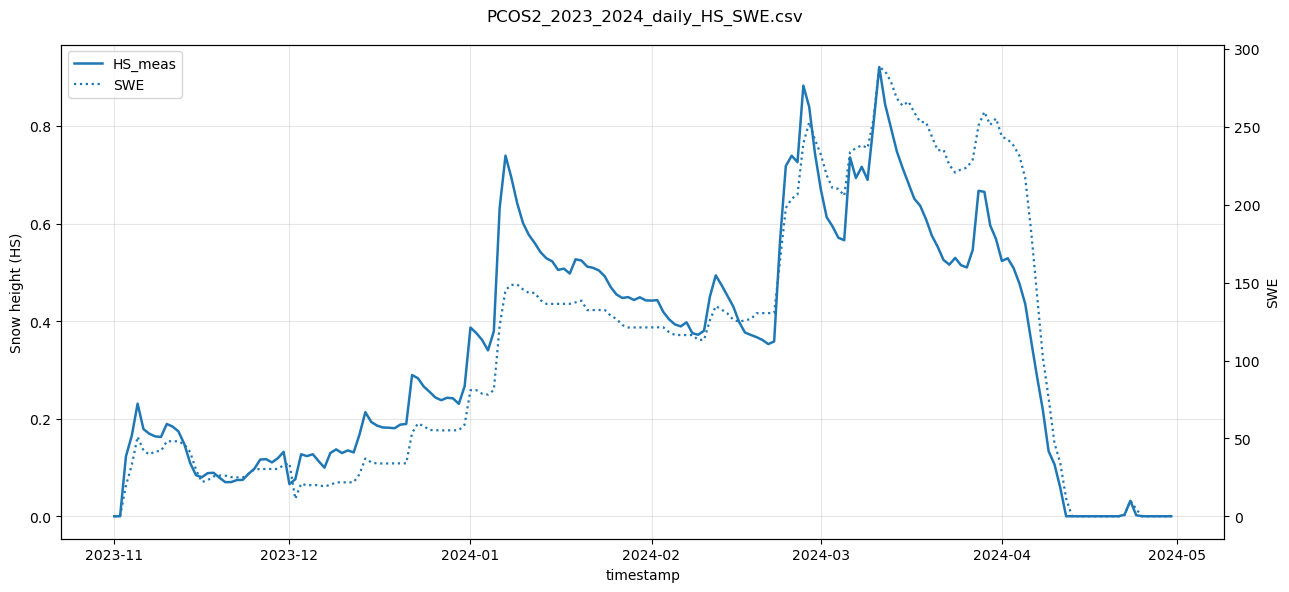

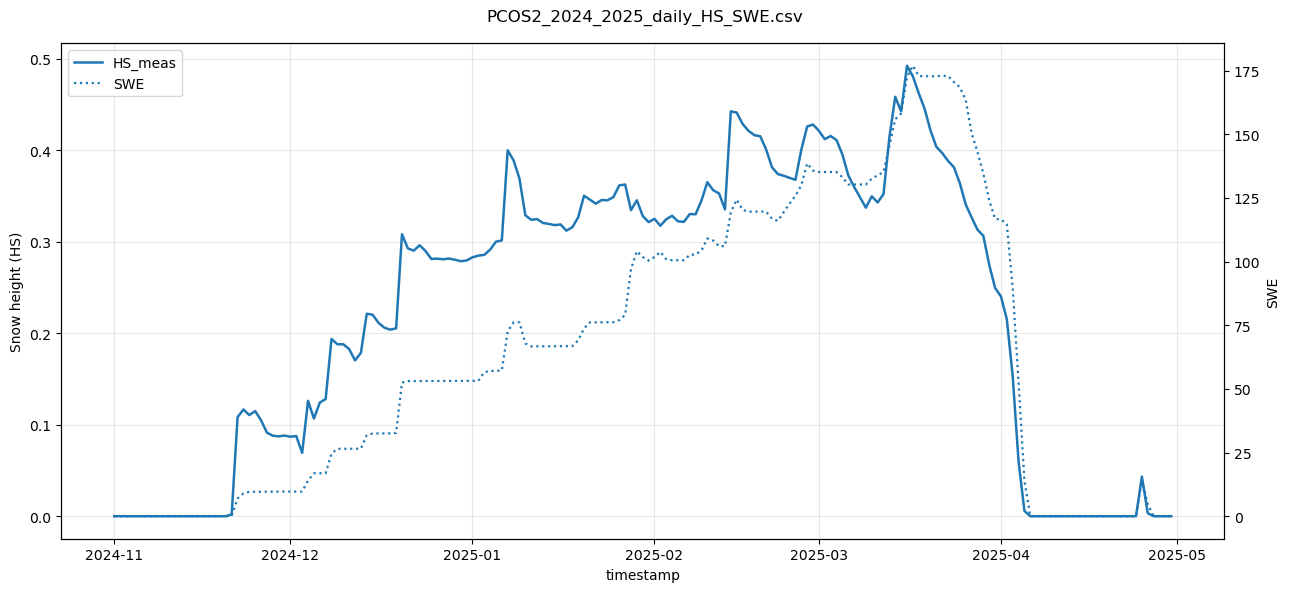

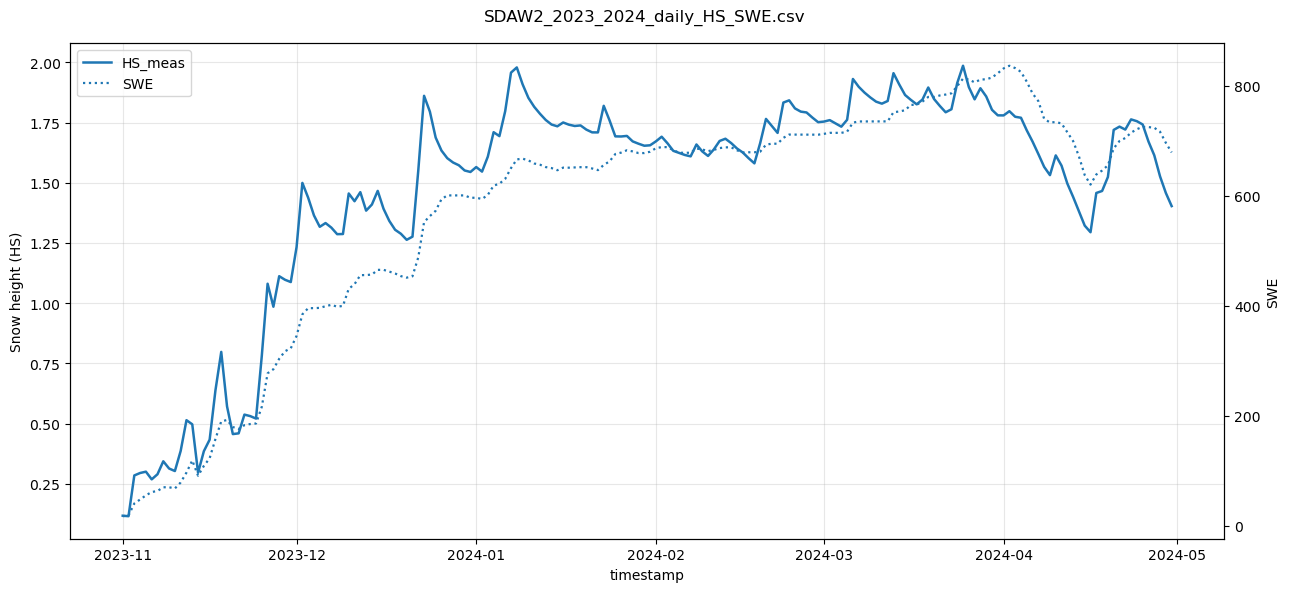

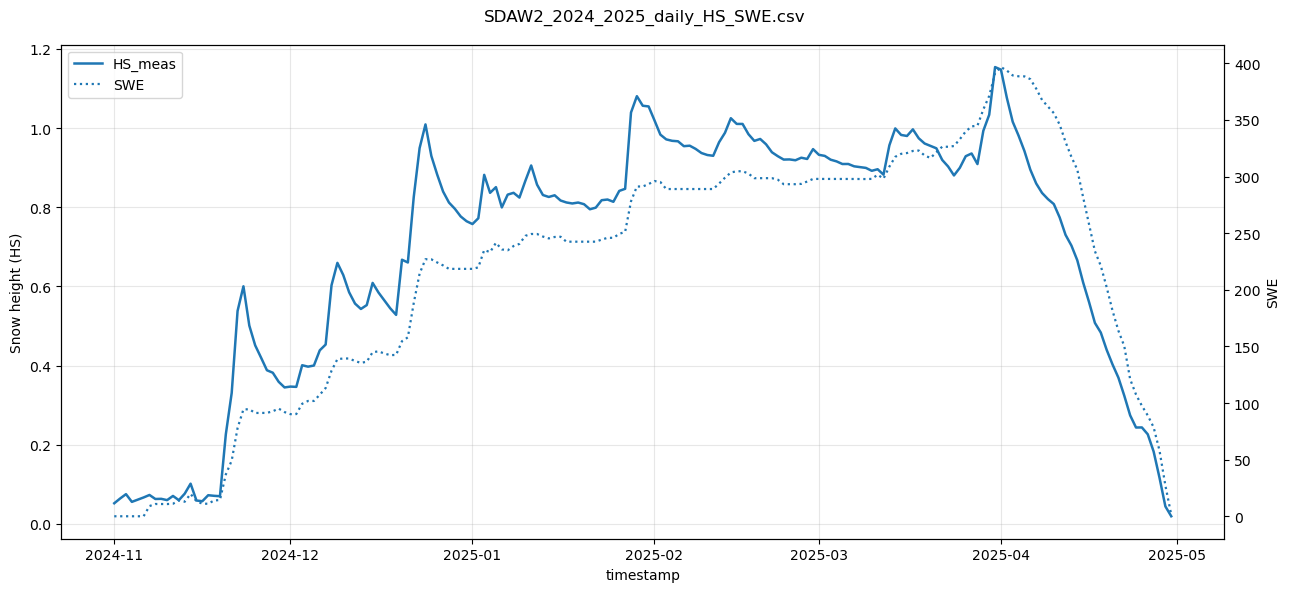

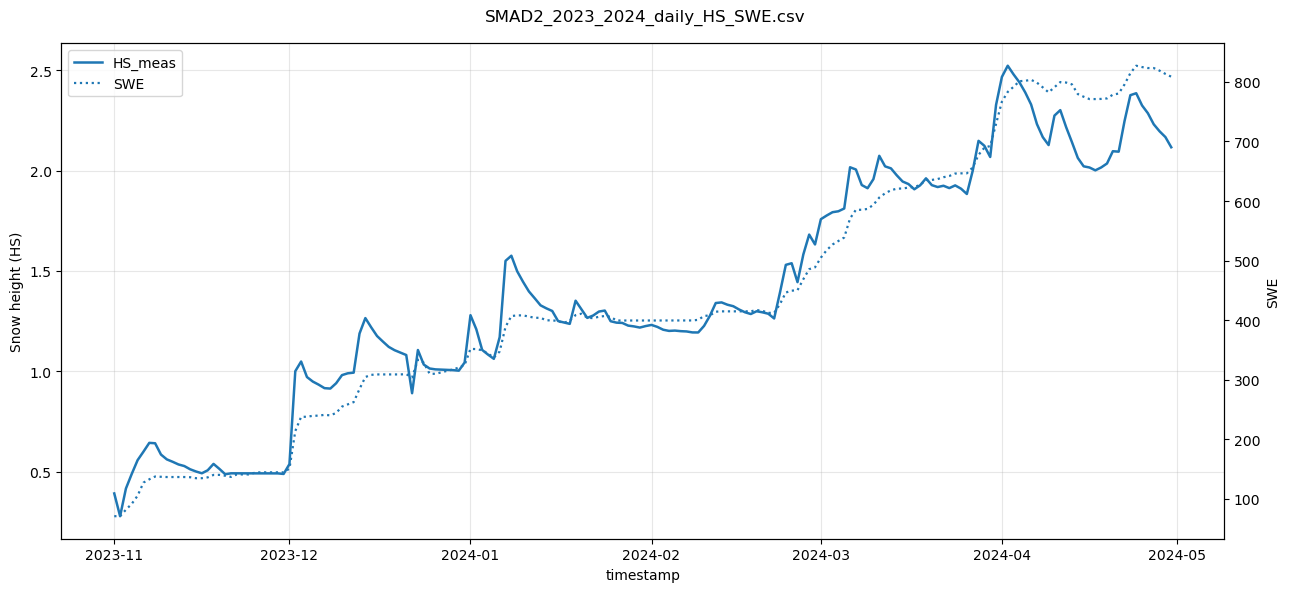

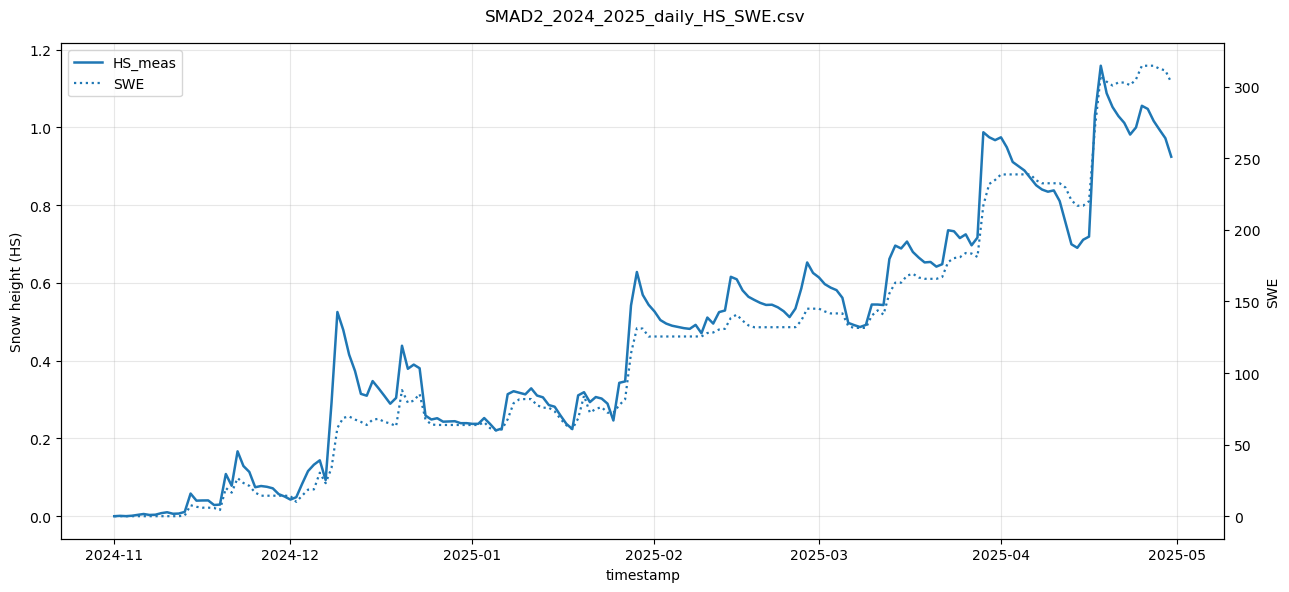

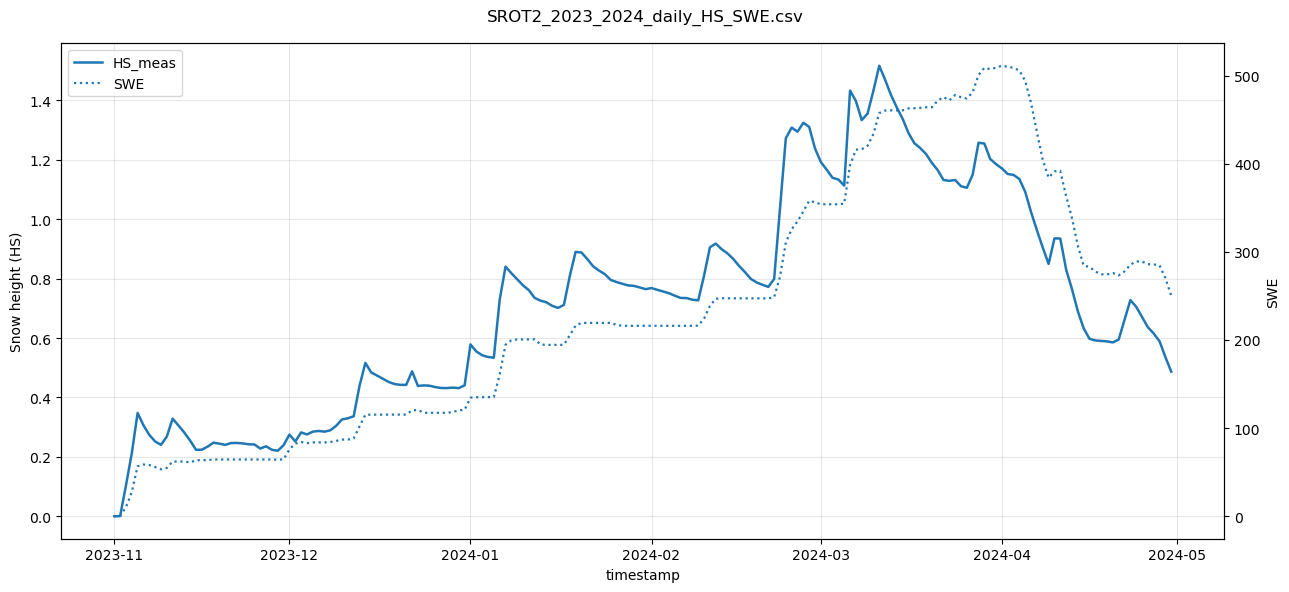

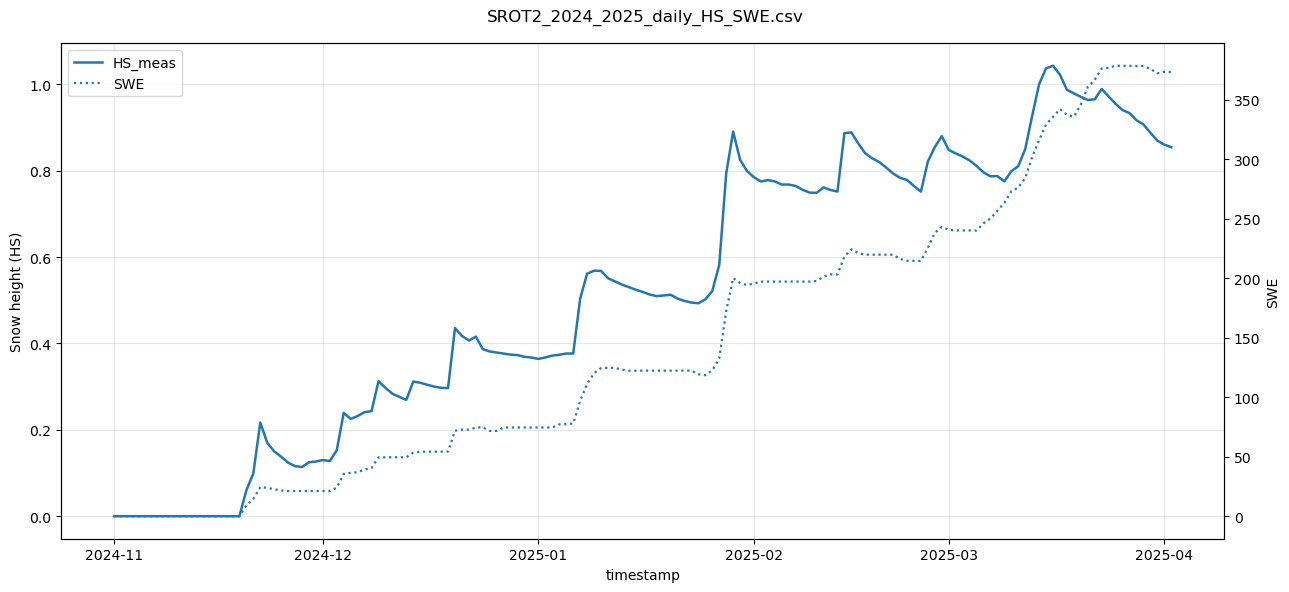

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow/par_sens/SNOWPACK_data_seasons_daily")
csv_files = sorted(data_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {data_dir}")

def _norm(s: str) -> str:
    return "".join(ch for ch in s.lower() if ch.isalnum())

def find_col(columns, candidates):
    norm_map = {_norm(c): c for c in columns}
    for cand in candidates:
        c = norm_map.get(_norm(cand))
        if c is not None:
            return c
    return None

for f in csv_files:
    # Try comma first, then semicolon
    try:
        df = pd.read_csv(f)
        if df.shape[1] == 1:
            df = pd.read_csv(f, sep=";")
    except Exception:
        df = pd.read_csv(f, sep=";")

    # Time axis
    date_col = find_col(df.columns, ["date", "time", "timestamp", "datetime", "datum", "day"])
    if date_col:
        x = pd.to_datetime(df[date_col], errors="coerce")
        x_label = date_col
    else:
        x = df.index
        x_label = "index"

    # HS columns
    hs_meas_col = find_col(
        df.columns,
        ["hs_measured", "hs_meas", "hs_obs", "hs_observed",
         "snowheight_measured", "measured_snow_height"]
    )
    hs_mod_col = find_col(
        df.columns,
        ["hs_modelled", "hs_modeled", "hs_sim", "hs_model",
         "snowheight_modelled", "modelled_snow_height"]
    )

    # SWE columns (anything containing "swe")
    swe_cols = [c for c in df.columns if "swe" in c.lower()]

    # ------------------------------------------------------------
    # ONE FIGURE: HS + SWE on same axes (twin y-axis)
    # ------------------------------------------------------------
    fig, ax_hs = plt.subplots(figsize=(13, 6))
    fig.suptitle(f.name)

    # HS axis (left)
    plotted_any = False
    if hs_meas_col:
        ax_hs.plot(x, df[hs_meas_col], label=hs_meas_col, linewidth=1.8)
        plotted_any = True
    if hs_mod_col:
        ax_hs.plot(x, df[hs_mod_col], label=hs_mod_col, linewidth=1.8, linestyle="--")
        plotted_any = True

    ax_hs.set_ylabel("Snow height (HS)")
    ax_hs.set_xlabel(x_label)
    ax_hs.grid(True, alpha=0.3)

    # SWE axis (right)
    ax_swe = ax_hs.twinx()
    if swe_cols:
        for c in swe_cols:
            ax_swe.plot(x, df[c], label=c, linewidth=1.6, linestyle=":")
            plotted_any = True
    ax_swe.set_ylabel("SWE")

    # Combined legend (HS + SWE)
    handles_hs, labels_hs = ax_hs.get_legend_handles_labels()
    handles_swe, labels_swe = ax_swe.get_legend_handles_labels()
    if handles_hs or handles_swe:
        ax_hs.legend(handles_hs + handles_swe, labels_hs + labels_swe, loc="upper left")

    if not plotted_any:
        ax_hs.text(0.5, 0.5, "No HS/SWE columns found", transform=ax_hs.transAxes,
                   ha="center", va="center")

    plt.tight_layout()
    plt.show()